# Derivative Pricing CW


## 1 - Data Collection

In [64]:
import pandas as pd
import warnings
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import CubicSpline

FILE_PATH = "Bloomberg - Historical Data v2026-01-21.xlsx"
table_mapping = {"gbp ois results":[] ,
    "eur estr results":[],
    "usd sofr results":[]
}
ticker_mapping = {"gbp ois results":['BPSWS',' Curncy'] ,
    "eur estr results":['EESWE',' Curncy'],
    "usd sofr results":['USOSFR',' Curncy']
}

for item in ticker_mapping:
    for i in ['2', '3', '5', '10', '15', '20', '30']:
        table_mapping[item].append(ticker_mapping[item][0]+i+ticker_mapping[item][1])
print(table_mapping)

{'gbp ois results': ['BPSWS2 Curncy', 'BPSWS3 Curncy', 'BPSWS5 Curncy', 'BPSWS10 Curncy', 'BPSWS15 Curncy', 'BPSWS20 Curncy', 'BPSWS30 Curncy'], 'eur estr results': ['EESWE2 Curncy', 'EESWE3 Curncy', 'EESWE5 Curncy', 'EESWE10 Curncy', 'EESWE15 Curncy', 'EESWE20 Curncy', 'EESWE30 Curncy'], 'usd sofr results': ['USOSFR2 Curncy', 'USOSFR3 Curncy', 'USOSFR5 Curncy', 'USOSFR10 Curncy', 'USOSFR15 Curncy', 'USOSFR20 Curncy', 'USOSFR30 Curncy']}


In [45]:
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
TARGET_TENORS = ['2Y', '3Y', '5Y', '10Y', '15Y', '20Y', '30Y']
def find_ticker_col(raw_df, ticker):
    for col in range(raw_df.shape[1]):
        cell = str(raw_df.iloc[0, col]).strip()
        if ticker.lower() in cell.lower():
            return col
    return None
def get_data(SHEET_NAME):
    raw = pd.read_excel(FILE_PATH, sheet_name=SHEET_NAME, header=None)
    ticker_col_map = {}
    for ticker, tenor in zip(table_mapping[SHEET_NAME], TARGET_TENORS):
        col_idx = find_ticker_col(raw, ticker)
        
        ticker_col_map[tenor] = {
            "ticker": ticker,
            "date_col": col_idx - 1,   
            "rate_col": col_idx        
        }
    

    result_df = None

    for tenor, info in ticker_col_map.items():
        date_series = raw.iloc[1:, info["date_col"]]
        rate_series = raw.iloc[1:, info["rate_col"]]

        temp_df = pd.DataFrame({
            "Date": pd.to_datetime(date_series.values, errors="coerce", format="mixed"),
            tenor: pd.to_numeric(rate_series.values, errors="coerce")
        }).dropna(subset=["Date"])

        if result_df is None:
            result_df = temp_df
        else:
            result_df = pd.merge(result_df, temp_df, on="Date", how="outer")

    result_df = result_df.sort_values("Date")
    start_date = pd.Timestamp("2023-01-30")
    result_df = result_df.dropna(subset=TARGET_TENORS)
    result_df = result_df[result_df["Date"] >= start_date]
    result_df = result_df.reset_index(drop=True)
    return result_df

result_usd = get_data("usd sofr results")
result_gbp = get_data("gbp ois results")
result_eur = get_data("eur estr results")

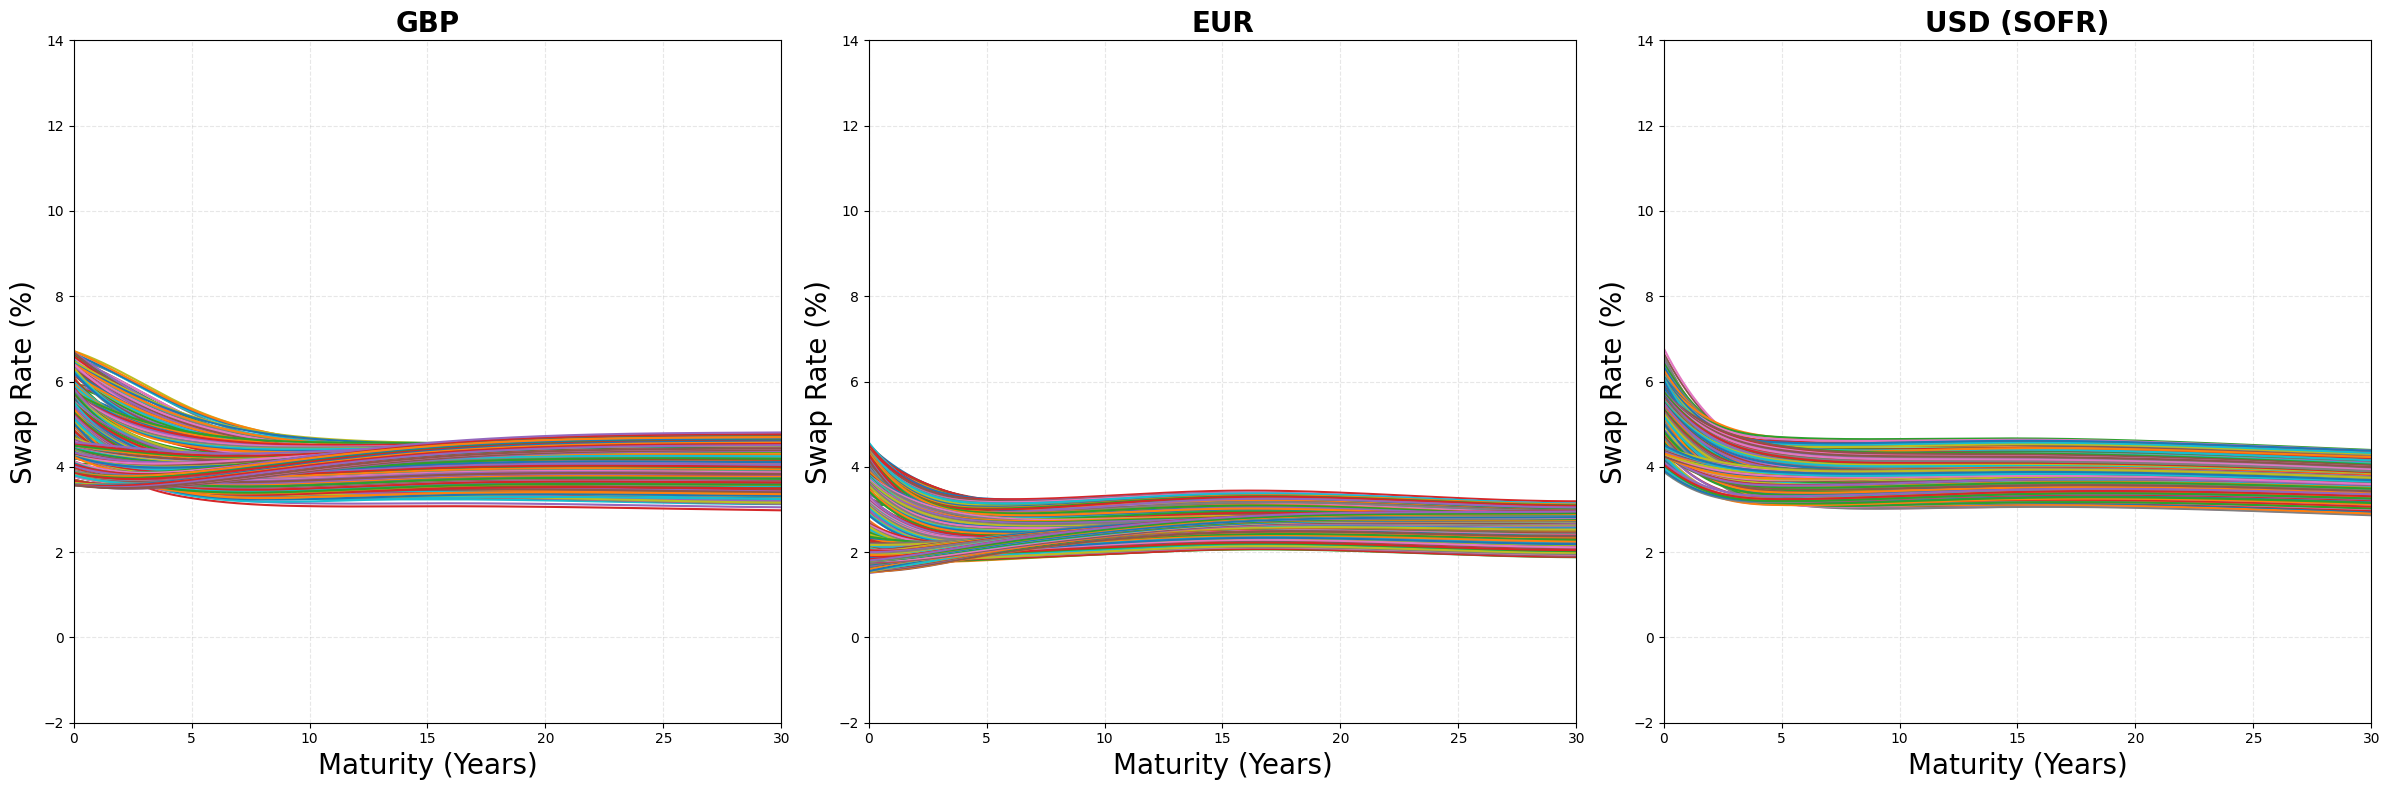

In [66]:
TENORS_LABEL = ['2Y', '3Y', '5Y', '10Y', '15Y', '20Y', '30Y']
TENORS_NUM   = [2, 3, 5, 10, 15, 20, 30] 

fig, axes = plt.subplots(1, 3, figsize=(24, 8)) 

datasets = [
    (result_gbp, "GBP"),
    (result_eur, "EUR"),
    (result_usd, "USD (SOFR)")
]

x_smooth = np.linspace(0, 30, 300)

for ax, (df, currency_name) in zip(axes, datasets):
    for _, row in df.iterrows():
        rates = [row[t] for t in TENORS_LABEL]
        
        cs = CubicSpline(TENORS_NUM, rates)
        y_smooth = cs(x_smooth)
        
        ax.plot(x_smooth, y_smooth)

    ax.set_title(f"{currency_name}", fontsize=20, fontweight="bold")
    ax.set_xlabel("Maturity (Years)", fontsize=20)
    ax.set_ylabel("Swap Rate (%)", fontsize=20)

    ax.set_xlim(0, 30)
    ax.set_ylim(-2, 14)
    ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()
plt.show()

In [69]:
result_eur

,Date,2Y,3Y,5Y,10Y,15Y,20Y,30Y
0,2023-01-30,3.07300,2.87900,2.6830,2.6240,2.65000,2.54825,2.2740
1,2023-01-31,3.06350,2.86550,2.6685,2.6110,2.64300,2.53900,2.2770
2,2023-02-01,3.07700,2.87400,2.6820,2.5985,2.62600,2.51400,2.2500
3,2023-02-02,2.92425,2.69450,2.4820,2.4120,2.45900,2.37700,2.1470
4,2023-02-03,2.99000,2.74400,2.5640,2.5150,2.56900,2.48700,2.2580
...,...,...,...,...,...,...,...,...
720,2025-11-26,1.91000,1.98300,2.1481,2.5030,2.74410,2.85000,2.8860
721,2025-11-27,1.91800,1.99400,2.1620,2.5090,2.75110,2.85760,2.8950
722,2025-11-28,1.92400,2.00200,2.1690,2.5277,2.77125,2.87700,2.9139
723,2025-12-01,1.94900,2.03195,2.2116,2.5740,2.81510,2.92200,2.9600


In [2]:
import pandas as pd
import numpy as np
import warnings
import torch
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

# ── 论文设定 ──────────────────────────────────────
S_MIN = -0.05        # -5%（小数形式）
S_MAX =  0.25        # 25%（小数形式）
MATURITIES = [2, 3, 5, 10, 15, 20, 30]
TARGET_TENORS = ['2Y', '3Y', '5Y', '10Y', '15Y', '20Y', '30Y']

# ── 你的文件设定 ──────────────────────────────────
FILE_PATH = "Bloomberg - Historical Data v2026-01-21.xlsx"

CURRENCIES = ['GBP', 'EUR', 'USD']

SHEET_NAMES = {
    'GBP': 'gbp ois results',
    'EUR': 'eur estr results',
    'USD': 'usd sofr results'
}

TICKER_MAPPING = {
    'gbp ois results': ['BPSWS',  ' Curncy'],
    'eur estr results': ['EESWE', ' Curncy'],
    'usd sofr results': ['USOSFR',' Curncy']
}

TABLE_MAPPING = {}
for sheet, (prefix, suffix) in TICKER_MAPPING.items():
    TABLE_MAPPING[sheet] = [
        prefix + t + suffix
        for t in ['2', '3', '5', '10', '15', '20', '30']
    ]


# ── 你原来的读取函数（保持不变）────────────────────
def find_ticker_col(raw_df, ticker):
    for col in range(raw_df.shape[1]):
        cell = str(raw_df.iloc[0, col]).strip()
        if ticker.lower() in cell.lower():
            return col
    return None


def get_data(sheet_name, start_date="2023-01-30"):
    """
    读取单个货币的数据
    返回 DataFrame，列为 [Date, 2Y, 3Y, 5Y, 10Y, 15Y, 20Y, 30Y]
    利率单位：% （比如 4.52 表示 4.52%）
    """
    raw = pd.read_excel(FILE_PATH, sheet_name=sheet_name, header=None)

    ticker_col_map = {}
    for ticker, tenor in zip(TABLE_MAPPING[sheet_name], TARGET_TENORS):
        col_idx = find_ticker_col(raw, ticker)
        if col_idx is None:
            print(f"Warning: ticker {ticker} not found in {sheet_name}")
            continue
        ticker_col_map[tenor] = {
            "ticker":   ticker,
            "date_col": col_idx - 1,
            "rate_col": col_idx
        }

    result_df = None
    for tenor, info in ticker_col_map.items():
        date_series = raw.iloc[1:, info["date_col"]]
        rate_series = raw.iloc[1:, info["rate_col"]]

        temp_df = pd.DataFrame({
            "Date": pd.to_datetime(
                date_series.values, errors="coerce", format="mixed"
            ),
            tenor: pd.to_numeric(rate_series.values, errors="coerce")
        }).dropna(subset=["Date"])

        result_df = temp_df if result_df is None else \
            pd.merge(result_df, temp_df, on="Date", how="outer")

    result_df = result_df.sort_values("Date")
    result_df = result_df.dropna(subset=TARGET_TENORS)
    result_df = result_df[
        result_df["Date"] >= pd.Timestamp(start_date)
    ]
    result_df = result_df.reset_index(drop=True)
    return result_df


def load_all_currencies(start_date="2023-01-30"):
    """
    加载所有货币的数据
    返回字典 {'GBP': df_gbp, 'EUR': df_eur, 'USD': df_usd}
    """
    dfs = {}
    for ccy in CURRENCIES:
        sheet = SHEET_NAMES[ccy]
        df = get_data(sheet, start_date)
        dfs[ccy] = df
        print(f"{ccy}: {len(df)} observations "
              f"({df['Date'].min().date()} to "
              f"{df['Date'].max().date()})")
    return dfs


# ── Dataset 类 ────────────────────────────────────
class SwapRateDataset(Dataset):
    """
    PyTorch Dataset for multi-currency swap rates

    每个样本：
        x:     (7,)  归一化的互换利率 [0,1]
        label: int   货币索引 (0=GBP, 1=EUR, 2=USD)
    """

    def __init__(self, dfs, currencies=CURRENCIES,
                 train=True, split_date='2024-01-01'):
        """
        Args:
            dfs:        load_all_currencies() 的输出
            currencies: 使用的货币列表
            train:      True=训练集, False=测试集
            split_date: 训练/测试分割日期
        """
        self.currencies = currencies
        self.split_date = pd.Timestamp(split_date)
        self.train = train

        self.data, self.labels, self.dates = \
            self._prepare(dfs)

    def _prepare(self, dfs):
        all_rates  = []
        all_labels = []
        all_dates  = []

        for ccy_idx, ccy in enumerate(self.currencies):
            df = dfs[ccy].copy()

            # ── 按日期分割 ────────────────────────
            if self.train:
                df = df[df['Date'] <= self.split_date]
            else:
                df = df[df['Date'] > self.split_date]

            if len(df) == 0:
                print(f"Warning: No data for {ccy} "
                      f"in {'train' if self.train else 'test'} set")
                continue

            # ── 提取利率矩阵 ──────────────────────
            # 单位：%，比如 4.52
            rates_pct = df[TARGET_TENORS].values  # (N, 7)

            # ── 转换为小数 ────────────────────────
            # 4.52% → 0.0452
            rates = rates_pct / 100.0

            # ── 归一化到 [0, 1] ───────────────────
            # 论文: 从 [-5%, 25%] 线性映射到 [0, 1]
            rates_norm = (rates - S_MIN) / (S_MAX - S_MIN)
            rates_norm = np.clip(rates_norm, 0.0, 1.0)

            all_rates.append(rates_norm.astype(np.float32))
            all_labels.append(
                np.full(len(rates_norm), ccy_idx, dtype=np.int64)
            )
            all_dates.extend(df['Date'].tolist())

            split_str = 'train' if self.train else 'test'
            print(f"  {ccy} ({split_str}): {len(rates_norm)} obs")

        if len(all_rates) == 0:
            raise ValueError("No data loaded!")

        data   = np.vstack(all_rates)
        labels = np.concatenate(all_labels)

        return data, labels, all_dates

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return (
            torch.tensor(self.data[idx],   dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.long)
        )

    def get_rates_original(self, idx):
        """
        返回原始利率（%单位），用于可视化
        """
        rates_norm = self.data[idx]
        rates = rates_norm * (S_MAX - S_MIN) + S_MIN
        return rates * 100.0  # 转回 %


def get_dataloaders(dfs, currencies=CURRENCIES,
                    batch_size=64, split_date='2024-01-01'):
    """
    返回训练/测试 DataLoader 和 Dataset

    注意：你的数据从 2023-01-30 开始
    split_date 建议设为 '2024-06-01' 或 '2024-01-01'
    """
    print("\nPreparing training set:")
    train_dataset = SwapRateDataset(
        dfs, currencies, train=True,  split_date=split_date
    )

    print("\nPreparing test set:")
    test_dataset = SwapRateDataset(
        dfs, currencies, train=False, split_date=split_date
    )

    train_loader = DataLoader(
        train_dataset, batch_size=batch_size,
        shuffle=True, drop_last=False
    )
    test_loader = DataLoader(
        test_dataset, batch_size=batch_size,
        shuffle=False, drop_last=False
    )

    print(f"\nTotal train samples: {len(train_dataset)}")
    print(f"Total test  samples: {len(test_dataset)}")

    return train_loader, test_loader, train_dataset, test_dataset

In [3]:
dfs = load_all_currencies(start_date="2023-01-30")
dfs

GBP: 716 observations (2023-01-30 to 2025-11-26)
EUR: 725 observations (2023-01-30 to 2025-12-02)
USD: 461 observations (2023-01-30 to 2024-11-26)


{'GBP':           Date       2Y       3Y       5Y      10Y      15Y      20Y      30Y
 0   2023-01-30  4.07450  3.85840  3.61760  3.38150  3.34050  3.29450  3.18350
 1   2023-01-31  4.04160  3.82800  3.60380  3.37950  3.34750  3.30787  3.20230
 2   2023-02-01  4.00578  3.78940  3.57320  3.36200  3.33700  3.28710  3.18810
 3   2023-02-02  3.78910  3.53220  3.26690  3.07695  3.07600  3.06200  2.98000
 4   2023-02-03  3.81490  3.57350  3.32880  3.14340  3.14510  3.13010  3.05160
 ..         ...      ...      ...      ...      ...      ...      ...      ...
 711 2025-11-20  3.54861  3.57825  3.69385  4.05544  4.34157  4.49396  4.57062
 712 2025-11-21  3.53550  3.56400  3.67400  4.02450  4.30550  4.45600  4.53150
 713 2025-11-24  3.55750  3.58700  3.69150  4.03068  4.31081  4.46150  4.53700
 714 2025-11-25  3.52160  3.54533  3.65050  3.99795  4.27910  4.43010  4.50690
 715 2025-11-26  3.50050  3.51696  3.61150  3.94180  4.21550  4.36145  4.43175
 
 [716 rows x 8 columns],
 'EUR':           